## Vectors

## Vector Use Cases in ML/Data Science
- **Data Representation**: Each data point can be represented as a vector in a high-dimensional space (e.g., word embeddings, image pixels).
- **Similarity Measurement**: Dot product and cosine similarity are used to measure similarity between data points (e.g., in clustering, nearest neighbors).
- **Feature Transformation**: Linear transformations (e.g., PCA) involve eigenvectors and eigenvalues to reduce dimensionality while preserving variance.
- **Neural Networks**: Weights and activations in neural networks are represented as vectors, and operations like dot product are fundamental to forward and backward propagation.

### Words to Vectors (Word Embeddings)
- Word embeddings (e.g., Word2Vec, GloVe) represent words as dense vectors in a continuous vector space, capturing semantic relationships between words.

- **Bag-of-Words (BoW)**: A simple representation where each word is represented as a binary or count-based vector indicating the presence or frequency of words in a document.
- **Global Vectors for Word Representation (GloVe)**: A word embedding technique that captures global statistical information of a corpus by factorizing a word co-occurrence matrix.
- **word2vec**: A popular word embedding method that uses a shallow neural network to learn word representations based on the context in which words appear in a corpus. It captures semantic relationships between words, allowing for operations like vector arithmetic (e.g., "king" - "man" + "woman" ≈ "queen").



##  bag‑of‑words (BoW) model – a binary or count‑based BoW with a limited vocabulary

3D vectors [ai, data, learning]:
S1: [1. 1. 0.]
S2: [0. 1. 1.]
S3: [0. 0. 0.]
S4: [1. 1. 0.]

Cosine Similarity Matrix:
[[1.  0.5 0.  1. ]
 [0.5 1.  0.  0.5]
 [0.  0.  0.  0. ]
 [1.  0.5 0.  1. ]]

New sentence vector: [0. 0. 1.]

Similarities with new sentence:
  S1: 0.000
  S2: 0.707
  S3: 0.000
  S4: 0.000


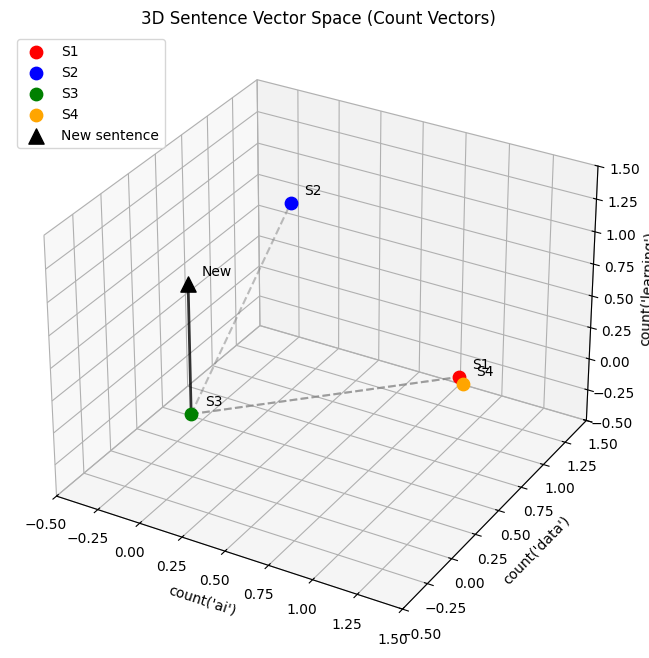

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Sample sentences
sentences = [
    "AI loves data science",
    "Machine learning uses data",
    "I enjoy pizza and music",
    "Data science and AI are related"
]

features = ["ai", "data", "learning"]

# Convert sentences to count vectors
vectors_3d = []
for s in sentences:
    tokens = s.lower().split()
    vec = [tokens.count(f) for f in features]
    vectors_3d.append(vec)

vectors_3d = np.array(vectors_3d, dtype=float)

print("3D vectors [ai, data, learning]:")
for i, v in enumerate(vectors_3d):
    print(f"S{i+1}: {v}")

def cosine_sim(u, v):
    nu = np.linalg.norm(u)
    nv = np.linalg.norm(v)
    if nu == 0 or nv == 0:
        return 0.0
    return np.dot(u, v) / (nu * nv)

# Similarity matrix
n = len(vectors_3d)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = cosine_sim(vectors_3d[i], vectors_3d[j])

print("\nCosine Similarity Matrix:")
print(np.round(sim_matrix, 3))

# New sentence
new_sentence = "Machine learning is fun"
new_vec = np.array([new_sentence.lower().split().count(f) for f in features], dtype=float)
print(f"\nNew sentence vector: {new_vec}")

# Similarities with existing
print("\nSimilarities with new sentence:")
for i, vec in enumerate(vectors_3d):
    sim = cosine_sim(new_vec, vec)
    print(f"  S{i+1}: {sim:.3f}")

# 3D visualization with improvements
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Colors for each sentence
colors = ['red', 'blue', 'green', 'orange']

# Add a small jitter to overlapping points (S1 and S4 both [1,1,0])
jitter = 0.05
points = vectors_3d.copy()
# Apply jitter only to S4 (index 3) if it overlaps exactly with S1
if np.array_equal(points[0], points[3]):
    points[3] += np.array([jitter, -jitter, 0])

for i, vec in enumerate(points):
    ax.scatter(vec[0], vec[1], vec[2], s=80, color=colors[i], label=f"S{i+1}")
    ax.text(vec[0] + 0.05, vec[1] + 0.05, vec[2] + 0.05, f"S{i+1}", fontsize=10)

# Draw lines from origin to each original vector (without jitter)
for vec in vectors_3d:
    ax.plot([0, vec[0]], [0, vec[1]], [0, vec[2]], color='gray', linestyle='--', alpha=0.5)

# New sentence vector (black, triangle marker)
ax.scatter(new_vec[0], new_vec[1], new_vec[2], s=120, color='black', marker='^', label='New sentence')
ax.text(new_vec[0] + 0.05, new_vec[1] + 0.05, new_vec[2] + 0.05, "New", fontsize=10, color='black')
ax.plot([0, new_vec[0]], [0, new_vec[1]], [0, new_vec[2]], color='black', linestyle='-', linewidth=2, alpha=0.8)

# Set axis limits to ensure all points are visible
max_val = max(np.max(vectors_3d), np.max(new_vec)) + 0.5
ax.set_xlim(-0.5, max_val)
ax.set_ylim(-0.5, max_val)
ax.set_zlim(-0.5, max_val)

ax.set_xlabel("count('ai')")
ax.set_ylabel("count('data')")
ax.set_zlabel("count('learning')")
ax.set_title("3D Sentence Vector Space (Count Vectors)")
ax.legend(loc='upper left')
plt.show()

## Global Vectors for Word Representation (GloVe) - 

Sentences:
S1: AI loves data science
S2: Machine learning uses data
S3: I enjoy pizza and music
S4: Data science and AI are related

New sentence: Artificial intelligence and machine learning are powerful

Cosine similarities:
S1: 0.7571
S2: 0.8810
S3: 0.7579
S4: 0.9151

Most similar sentence: S4 ('Data science and AI are related') with similarity 0.9151


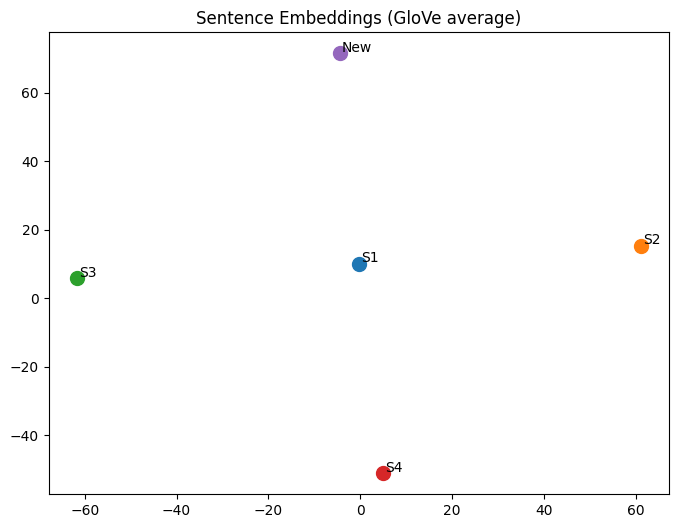

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import gensim.downloader as api

# Download a small pre-trained model (50 dimensions)
model = api.load("glove-wiki-gigaword-50")


def sentence_vector(sentence, model):
    """Average word vectors for words in a sentence (ignoring OOV words)."""
    words = sentence.lower().split()
    vectors = [model[w] for w in words if w in model]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)


def cosine_sim(u, v):
    nu = np.linalg.norm(u)
    nv = np.linalg.norm(v)
    if nu == 0 or nv == 0:
        return 0.0
    return float(np.dot(u, v) / (nu * nv))


# Example sentences
sentences = [
    "AI loves data science",
    "Machine learning uses data",
    "I enjoy pizza and music",
    "Data science and AI are related",
]

# Compute sentence vectors
sentence_vecs = [sentence_vector(s, model) for s in sentences]

# New sentence
new_sentence = "Artificial intelligence and machine learning are powerful"
new_vec = sentence_vector(new_sentence, model)

# Compute similarities
print("Sentences:")
for i, s in enumerate(sentences):
    print(f"S{i+1}: {s}")
print(f"\nNew sentence: {new_sentence}")

print("\nCosine similarities:")
sims = []
for i, vec in enumerate(sentence_vecs):
    sim = cosine_sim(new_vec, vec)
    sims.append(sim)
    print(f"S{i+1}: {sim:.4f}")

best_idx = int(np.argmax(sims))
print(
    f"\nMost similar sentence: S{best_idx+1} ('{sentences[best_idx]}') "
    f"with similarity {sims[best_idx]:.4f}"
)

all_vecs = np.array(sentence_vecs + [new_vec])
labels = [f"S{i+1}" for i in range(len(sentences))] + ["New"]

# TSNE requires perplexity < number of samples.
perplexity = min(30, len(all_vecs) - 1)
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
vecs_2d = tsne.fit_transform(all_vecs)

plt.figure(figsize=(8, 6))
for i, (x, y) in enumerate(vecs_2d):
    plt.scatter(x, y, s=100)
    plt.annotate(labels[i], (x + 0.5, y + 0.5))
plt.title("Sentence Embeddings (GloVe average)")
plt.show()

### Dot Product 

In [1]:
import numpy as np
import matplotlib.pyplot as plt


vector_a = np.array([1, 2, 3])
vector_b = np.array([4, 5, 6])
dot_product = np.dot(vector_a, vector_b)
print("Dot Product:", dot_product)
### Euclidean Distance
euclidean_distance = np.linalg.norm(vector_a - vector_b)
print("Euclidean Distance:", euclidean_distance)
# Angle between two vectors 
cosine_similarity = np.dot(vector_a, vector_b) / (np.linalg.norm(vector_a) * np.linalg.norm(vector_b))
angle = np.arccos(cosine_similarity)
print("Angle (in radians):", angle)
print("Angle (in degrees):", np.degrees(angle))


Dot Product: 32
Euclidean Distance: 5.196152422706632
Angle (in radians): 0.2257261285527342
Angle (in degrees): 12.933154491899135


### Geometrical Interpretation of Dot Product

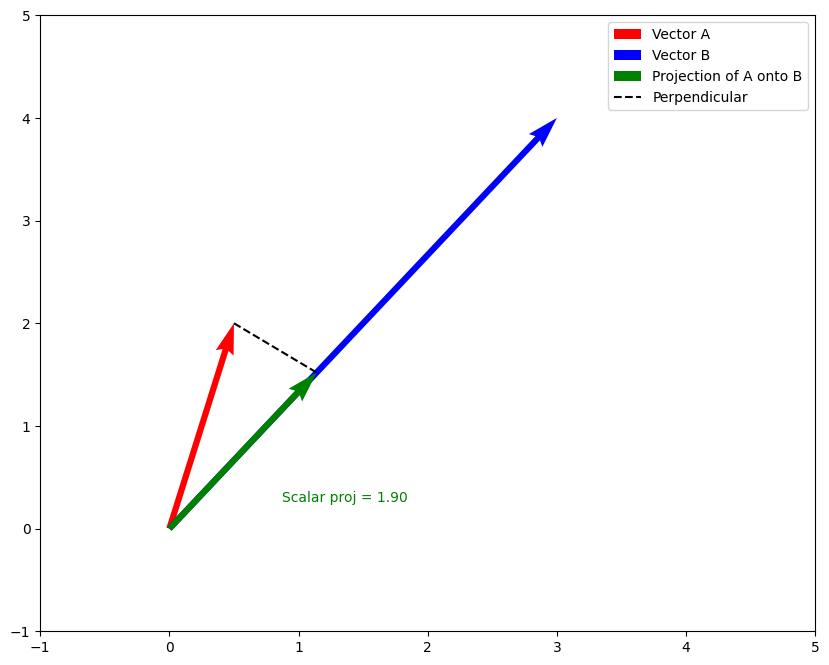

In [12]:
import numpy as np
import matplotlib.pyplot as plt

vector_a = np.array([0.5, 2]) 
vector_b = np.array([3, 4])

plt.figure(figsize=(10, 8))

# Plot original vectors
plt.quiver(0, 0, vector_a[0], vector_a[1], angles='xy', scale_units='xy', 
           scale=1, color='r', width=0.008, label='Vector A')

plt.quiver(0, 0, vector_b[0], vector_b[1], angles='xy', scale_units='xy', 
           scale=1, color='b', width=0.008, label='Vector B')

# Scalar projection of A onto B
scalar_proj = np.dot(vector_a, vector_b) / np.linalg.norm(vector_b)

# Vector projection of A onto B
b_direction = vector_b / np.linalg.norm(vector_b)
proj_vector = scalar_proj * b_direction

# Plot projection vector
plt.quiver(0, 0, proj_vector[0], proj_vector[1], angles='xy', scale_units='xy',
            scale=1, color='g', width=0.008, label=f'Projection of A onto B')

# Draw dashed line from tip of A to its projection
plt.plot([vector_a[0], proj_vector[0]], [vector_a[1], proj_vector[1]], 
            'k--', linewidth=1.5, label='Perpendicular')

# Annotate scalar projection
plt.annotate(f'Scalar proj = {scalar_proj:.2f}', 
                xy=(proj_vector[0]/2, proj_vector[1]/2),
                xytext=(proj_vector[0]/2 + 0.3, proj_vector[1]/2 - 0.5),
                fontsize=10, color='green')

plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.legend()
plt.show()

CROSS PRODUCT VISUALIZATION
Vector A = [3 2 0]
Vector B = [2 0 2]
A × B = [ 4 -6 -4]
Magnitude of A × B = 8.25


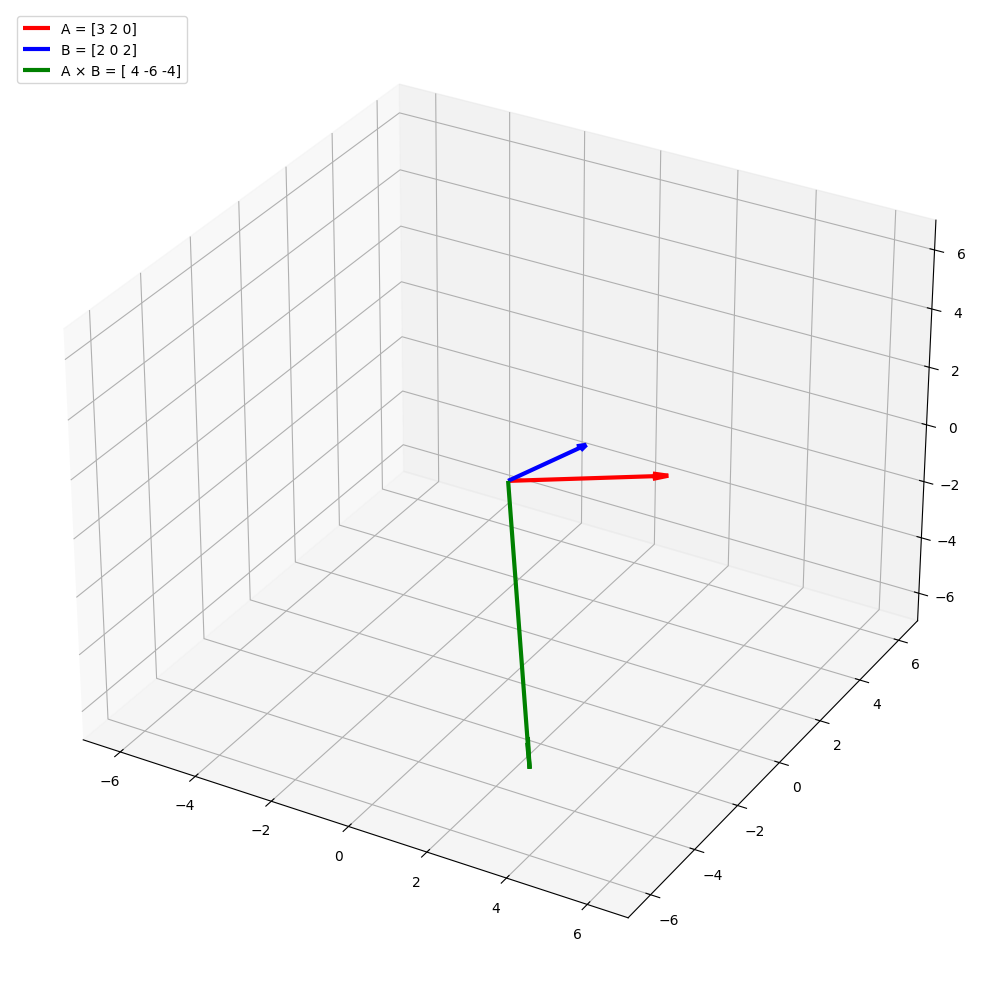

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# Vector A: pointing along X and Y
a = np.array([3, 2, 0])

# Vector B: pointing along X and Z
b = np.array([2, 0, 2])

# Calculate cross product: A × B
cross_product = np.cross(a, b)


print("=" * 50)
print("CROSS PRODUCT VISUALIZATION")
print("=" * 50)
print(f"Vector A = {a}")
print(f"Vector B = {b}")
print(f"A × B = {cross_product}")
print(f"Magnitude of A × B = {np.linalg.norm(cross_product):.2f}")
print("=" * 50)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Set the origin
origin = np.array([0, 0, 0])

# ============================================
# Plot the three vectors
# ============================================

ax.quiver(*origin, *a, color='red', linewidth=3, 
          arrow_length_ratio=0.1, label=f'A = {a}')

ax.quiver(*origin, *b, color='blue', linewidth=3, 
          arrow_length_ratio=0.1, label=f'B = {b}')

# Cross Product is perpendicular to both A and B
ax.quiver(*origin, *cross_product, color='green', linewidth=3, 
          arrow_length_ratio=0.1, label=f'A × B = {cross_product}')


max_coord = max(np.max(np.abs(a)), np.max(np.abs(b)), 
                np.max(np.abs(cross_product))) + 1

ax.set_xlim([-max_coord, max_coord])
ax.set_ylim([-max_coord, max_coord])
ax.set_zlim([-max_coord, max_coord])


ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()



## Visualizing Eigenvectors and Eigenvalues

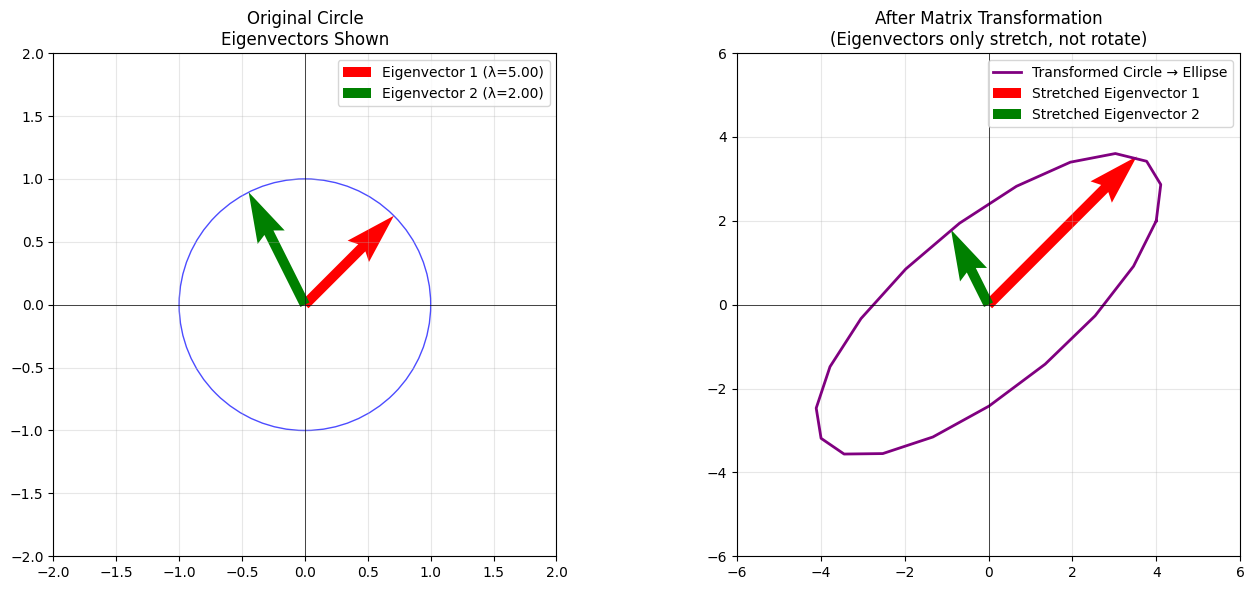


VISUALIZATION EXPLANATION:
Left plot: Unit circle with eigenvectors shown as arrows
Right plot: Circle transformed by matrix A into an ellipse
Notice: Eigenvectors remain on the SAME lines (only stretched)
Eigenvector 1 stretched by factor λ₁ = 5.00
Eigenvector 2 stretched by factor λ₂ = 2.00


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Matrix that stretches along [1,1] direction
A = np.array([[4, 1],
              [2, 3]])

# Calculate eigenvectors
eigenvals, eigenvecs = np.linalg.eig(A)

# Create a grid of points
theta = np.linspace(0, 2*np.pi, 20)
circle_points = np.array([np.cos(theta), np.sin(theta)])

# Transform the circle
transformed_points = A @ circle_points

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Original circle
ax1.add_patch(plt.Circle((0, 0), 1, fill=False, color='blue', alpha=0.7))
ax1.quiver(0, 0, eigenvecs[0,0], eigenvecs[1,0], angles='xy', scale_units='xy', 
           scale=1, color='red', width=0.02, label=f'Eigenvector 1 (λ={eigenvals[0]:.2f})')
ax1.quiver(0, 0, eigenvecs[0,1], eigenvecs[1,1], angles='xy', scale_units='xy', 
           scale=1, color='green', width=0.02, label=f'Eigenvector 2 (λ={eigenvals[1]:.2f})')
ax1.set_xlim(-2, 2)
ax1.set_ylim(-2, 2)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.set_title('Original Circle\nEigenvectors Shown')
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)
ax1.legend()

# Transformed ellipse
ax2.plot(transformed_points[0], transformed_points[1], 'purple', linewidth=2, label='Transformed Circle → Ellipse')
ax2.quiver(0, 0, eigenvals[0]*eigenvecs[0,0], eigenvals[0]*eigenvecs[1,0], 
           angles='xy', scale_units='xy', scale=1, color='red', width=0.02, 
           label=f'Stretched Eigenvector 1')
ax2.quiver(0, 0, eigenvals[1]*eigenvecs[0,1], eigenvals[1]*eigenvecs[1,1], 
           angles='xy', scale_units='xy', scale=1, color='green', width=0.02, 
           label=f'Stretched Eigenvector 2')
ax2.set_xlim(-6, 6)
ax2.set_ylim(-6, 6)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.set_title('After Matrix Transformation\n(Eigenvectors only stretch, not rotate)')
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("VISUALIZATION EXPLANATION:")
print("=" * 60)
print("Left plot: Unit circle with eigenvectors shown as arrows")
print("Right plot: Circle transformed by matrix A into an ellipse")
print("Notice: Eigenvectors remain on the SAME lines (only stretched)")
print(f"Eigenvector 1 stretched by factor λ₁ = {eigenvals[0]:.2f}")
print(f"Eigenvector 2 stretched by factor λ₂ = {eigenvals[1]:.2f}")

### Popular Activation Functions in Neural Networks
- **Sigmoid**: Maps input to a value between 0 and 1, often used in binary classification problems.
- **ReLU (Rectified Linear Unit)**: Outputs the input directly if it is positive; otherwise, it outputs zero. It is widely used in hidden layers of neural networks due to its simplicity and effectiveness in mitigating the vanishing gradient problem.
- **Tanh (Hyperbolic Tangent)**: Maps input to a value between -1 and 1, often used in hidden layers of neural networks, especially in recurrent neural networks (RNNs), as it can capture negative values and has a steeper gradient than sigmoid.
- **ELU** (Exponential Linear Unit): Similar to ReLU but allows for negative values, which can help improve learning in some cases by reducing bias shifts. It outputs the input directly if it is positive; otherwise, it outputs a scaled exponential function of the input.
- **Leaky ReLU**: A variant of ReLU that allows a small, non-zero gradient when the input is negative, which can help prevent the dying ReLU problem where neurons become inactive and only output zero.
- **Softmax**: Converts a vector of raw scores (logits) into probabilities, often used in the output layer of multi-class classification problems. It emphasizes the largest values and suppresses smaller ones, making it easier to interpret the output as probabilities.
-

## Sigmoid

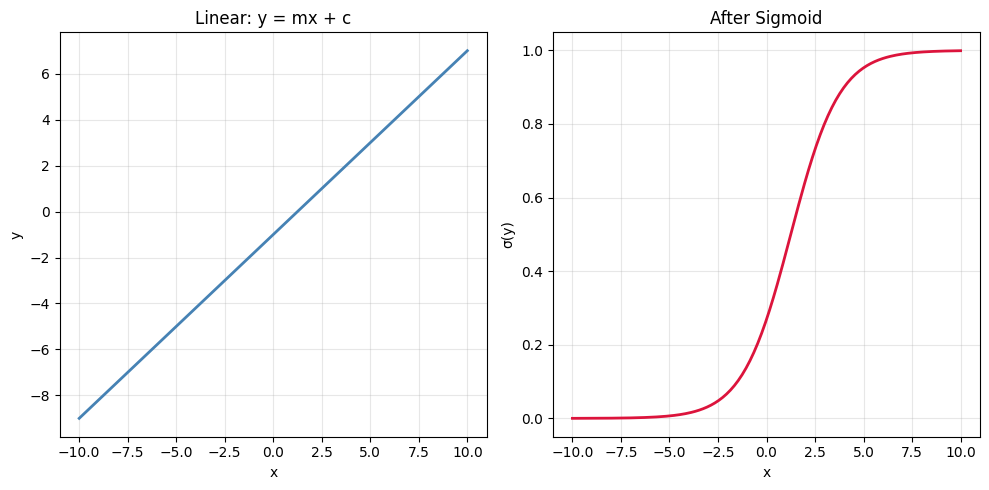

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data points
x = np.linspace(-10, 10, 200)
m, c = 0.8, -1.0
y_linear = m * x + c

y_sigmoid = 1 / (1 + np.exp(-y_linear))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, y_linear, color="steelblue", linewidth=2)
plt.title("Linear: y = mx + c")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x, y_sigmoid, color="crimson", linewidth=2)
plt.title("After Sigmoid")
plt.xlabel("x")
plt.ylabel("σ(y)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ReLu

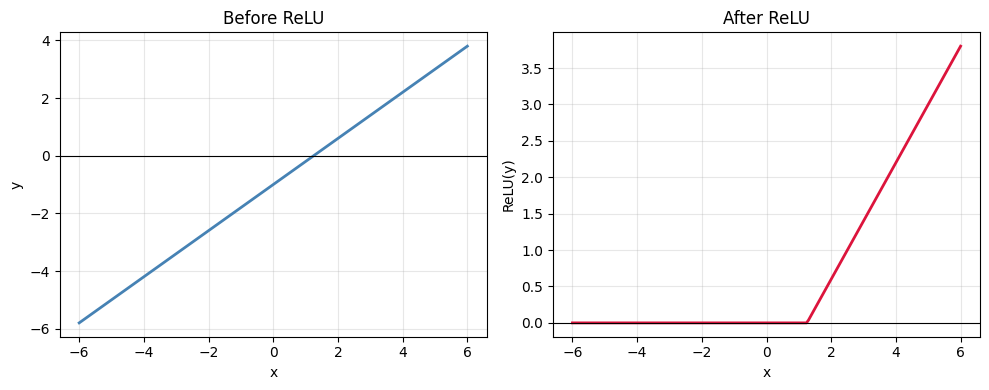

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data points
x = np.linspace(-6, 6, 200)
y_before = 0.8 * x - 1.0
y_after = np.maximum(0, y_before)  # ReLU

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(x, y_before, color="steelblue", linewidth=2)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Before ReLU")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x, y_after, color="crimson", linewidth=2)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("After ReLU")
plt.xlabel("x")
plt.ylabel("ReLU(y)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Tanh

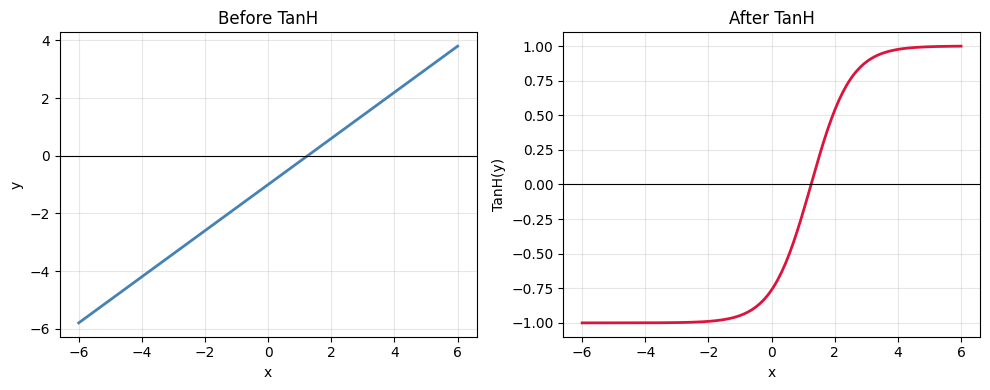

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data points
x = np.linspace(-6, 6, 200)
y_before = 0.8 * x - 1.0
y_after = np.tanh(y_before)  # TanH

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(x, y_before, color="steelblue", linewidth=2)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Before TanH")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x, y_after, color="crimson", linewidth=2)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("After TanH")
plt.xlabel("x")
plt.ylabel("TanH(y)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Softmax

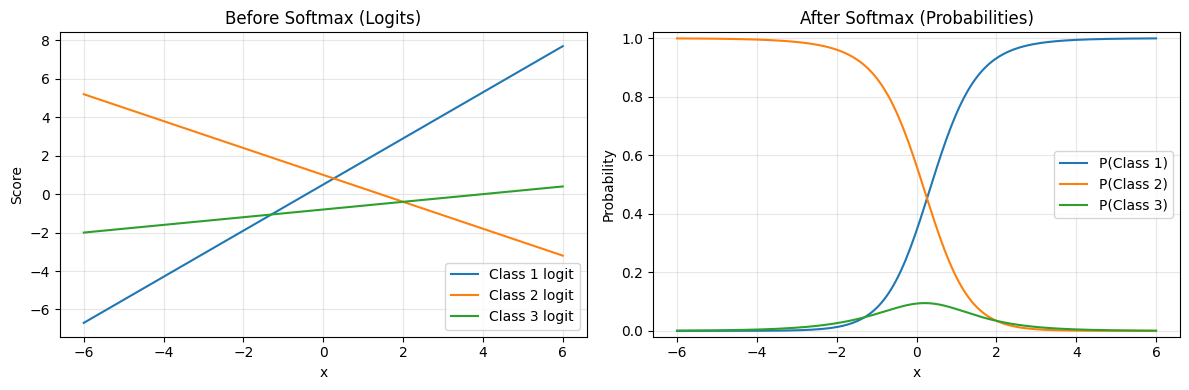

Softmax probabilities: [0.659  0.2424 0.0986]
Sum of probabilities: 1.0


In [28]:
# Softmax illustration: convert class scores (logits) into probabilities

x = np.linspace(-6, 6, 200)

# Three class logits as functions of x
logit_1 = 1.2 * x + 0.5
logit_2 = -0.7 * x + 1.0
logit_3 = 0.2 * x - 0.8

logits = np.vstack([logit_1, logit_2, logit_3])

# Numerically stable softmax
shifted = logits - np.max(logits, axis=0, keepdims=True)
exp_vals = np.exp(shifted)
softmax_probs = exp_vals / np.sum(exp_vals, axis=0, keepdims=True)

p1, p2, p3 = softmax_probs

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x, logit_1, label="Class 1 logit")
plt.plot(x, logit_2, label="Class 2 logit")
plt.plot(x, logit_3, label="Class 3 logit")
plt.title("Before Softmax (Logits)")
plt.xlabel("x")
plt.ylabel("Score")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x, p1, label="P(Class 1)")
plt.plot(x, p2, label="P(Class 2)")
plt.plot(x, p3, label="P(Class 3)")
plt.title("After Softmax (Probabilities)")
plt.xlabel("x")
plt.ylabel("Probability")
plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Example at a single point
sample_logits = np.array([2.0, 1.0, 0.1])
sample_exp = np.exp(sample_logits - np.max(sample_logits))
sample_probs = sample_exp / sample_exp.sum()
print("Softmax probabilities:", np.round(sample_probs, 4))
print("Sum of probabilities:", np.round(sample_probs.sum(), 4))

In [2]:
import numpy as np
values = np.array([2.0, 1.0, 0.1])
exp_vals = np.exp(values)
softmax_probs = exp_vals / np.sum(exp_vals, axis=0, keepdims=True)
print("Softmax probabilities:", np.round(softmax_probs, 4))


Softmax probabilities: [0.659  0.2424 0.0986]
